# Import

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# because i need to import this nlng rather than pyfim huhuhu
try:
    import pyfpgrowth
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyfpgrowth"])
    import pyfpgrowth

from sklearn.preprocessing import MultiLabelBinarizer
from collections import defaultdict

# Load Data

In [3]:
#folder_path = "/mnt/data/public/food-com-recipes/RAW_recipes.csv"
folder_path = "data/RAW_recipes.csv"
df = pd.read_csv(folder_path)

In [4]:
df.shape

(231637, 12)

# Data Preprocessing

We wont remove any of the null values since the relevant columns (tags, nutrition, and ingredients) are complete. Even if there are many nulls in description, that just means that the customer chose to not provide descriptive feedback. This should not affect our analysis.

In [5]:
df.isnull().sum()

,0
name,1
id,0
minutes,0
contributor_id,0
submitted,0
tags,0
nutrition,0
n_steps,0
steps,0
description,4979


In [6]:
# Convert the tags into a list
df["nutrition"] = df["nutrition"].apply(json.loads)
# Convert the tags into
df['tags'] = df['tags'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)
df['ingredients'] = df['ingredients'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)

# EDA

Hi bingbong insert EDA here please based on the plan

# Results and Discussion

## FIM all ingredients for both healthy food and every food


In [7]:
num_recipes = len(df['ingredients'])
min_support_pct = 0.02
minsup_count = max(1, int(num_recipes * min_support_pct))

all_freq_ingredients = pyfpgrowth.find_frequent_patterns(df['ingredients'].to_list(), minsup_count)

In [8]:
# Create a dictionary to store counts by itemset length
all_freq_counts = defaultdict(int)

for itemset in all_freq_ingredients.keys():
    k = len(itemset)  # length of the itemset
    all_freq_counts[k] += 1

# Convert to regular dict and optionally sort by k
all_freq_counts = dict(sorted(all_freq_counts.items()))
print(all_freq_counts)

all_three_itemsets = {k: v for k, v in all_freq_ingredients.items() if len(k) == 3}

{1: 54, 2: 72, 3: 32}


In [22]:
# --- Sort 3-itemsets by their support count (descending order) ---
sorted_three_itemsets = sorted(
    all_three_itemsets.items(),
    key=lambda x: x[1],   # sort by support count
    reverse=True          # highest first
)

# --- Get Top 10 most frequent 3-itemsets ---
top10_three_itemsets = sorted_three_itemsets[:10]

# --- Display results neatly ---
print("Top 10 most frequent 3-itemsets:")
for i, (items, count) in enumerate(top10_three_itemsets, start=1):
    print(f"{i}. {set(items)} -> {count}")


Top 10 most frequent 3-itemsets:
1. {'salt', 'butter', 'sugar'} -> 8817
2. {'salt', 'butter', 'flour'} -> 8460
3. {'eggs', 'salt', 'sugar'} -> 8195
4. {'eggs', 'salt', 'butter'} -> 8118
5. {'salt', 'flour', 'sugar'} -> 7868
6. {'salt', 'baking powder', 'sugar'} -> 7306
7. {'milk', 'salt', 'butter'} -> 6788
8. {'eggs', 'butter', 'sugar'} -> 6788
9. {'eggs', 'salt', 'baking powder'} -> 6558
10. {'onion', 'salt', 'pepper'} -> 6274


### Association Rules

In [23]:
# --- Generate association rules using FP-Growth results ---
min_confidence = 0.7
all_rules = pyfpgrowth.generate_association_rules(all_freq_ingredients, min_confidence)

# --- Total number of transactions (for calculating support) ---
num_transactions = len(df['ingredients'])

# --- Helper function to compute support ---
def get_support(itemset):
    """Return support of an itemset based on frequency counts."""
    return all_freq_ingredients.get(itemset, 0) / num_transactions

# --- Compute lift for each rule ---
lifted_rules = []

for antecedent, (consequent, confidence) in all_rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)

    # Avoid division by zero
    if consequent_support == 0:
        continue

    lift = confidence / consequent_support
    lifted_rules.append((antecedent, consequent, confidence, lift))

# --- Sort by confidence (and optionally by lift) ---
lifted_rules = sorted(lifted_rules, key=lambda x: (x[2], x[3]), reverse=True)

# --- Get Top 10 rules ---
top10_rules = lifted_rules[:10]

# --- Display neatly ---
print("Top 10 Association Rules (by confidence):")
for i, (antecedent, consequent, confidence, lift) in enumerate(top10_rules, start=1):
    print(f"{i}. {set(antecedent)} -> {set(consequent)} "
          f"(confidence = {confidence:.2f}, lift = {lift:.2f})")


Top 10 Association Rules (by confidence):
1. {'butter', 'pepper'} -> {'salt'} (confidence = 0.84, lift = 2.26)
2. {'onion', 'pepper'} -> {'salt'} (confidence = 0.81, lift = 2.20)
3. {'all-purpose flour', 'baking powder'} -> {'salt'} (confidence = 0.80, lift = 2.17)
4. {'eggs', 'baking soda'} -> {'salt'} (confidence = 0.80, lift = 2.15)
5. {'baking soda', 'baking powder'} -> {'salt'} (confidence = 0.79, lift = 2.14)
6. {'baking soda', 'sugar'} -> {'salt'} (confidence = 0.79, lift = 2.13)
7. {'baking soda', 'flour'} -> {'salt'} (confidence = 0.78, lift = 2.11)
8. {'baking powder', 'sugar'} -> {'salt'} (confidence = 0.78, lift = 2.10)
9. {'baking soda', 'butter'} -> {'salt'} (confidence = 0.77, lift = 2.07)
10. {'all-purpose flour', 'sugar'} -> {'salt'} (confidence = 0.76, lift = 2.05)


### Hyperparameter tuning

count    14904.000000
mean         0.000609
std          0.005804
min          0.000004
25%          0.000009
50%          0.000022
75%          0.000121
max          0.370174
Name: support, dtype: float64


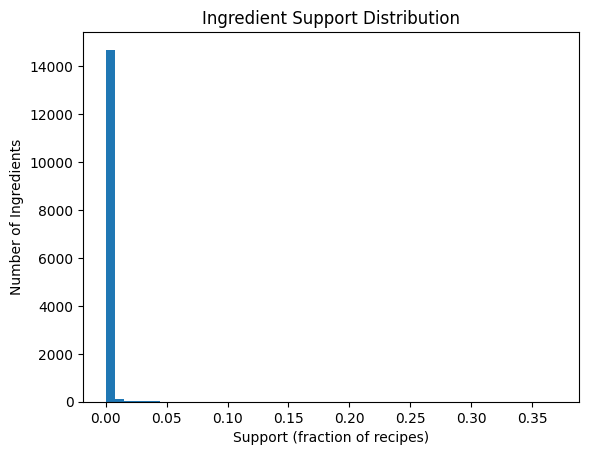

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Count how often each ingredient appears
ingredient_counts = Counter(
    ing for recipe in df['ingredients'] for ing in recipe
)

# Convert to DataFrame
ingredient_freq = pd.DataFrame.from_dict(ingredient_counts, orient='index', columns=['count'])
ingredient_freq['support'] = ingredient_freq['count'] / len(df)

# Sort descending
ingredient_freq = ingredient_freq.sort_values('support', ascending=False)

# Show summary statistics
print(ingredient_freq['support'].describe())

# Optional: plot histogram of item supports
plt.hist(ingredient_freq['support'], bins=50)
plt.title("Ingredient Support Distribution")
plt.xlabel("Support (fraction of recipes)")
plt.ylabel("Number of Ingredients")
plt.show()

count    100.000000
mean       0.658719
std        0.107727
min        0.500729
25%        0.565981
50%        0.642761
75%        0.772963
max        0.865385
dtype: float64


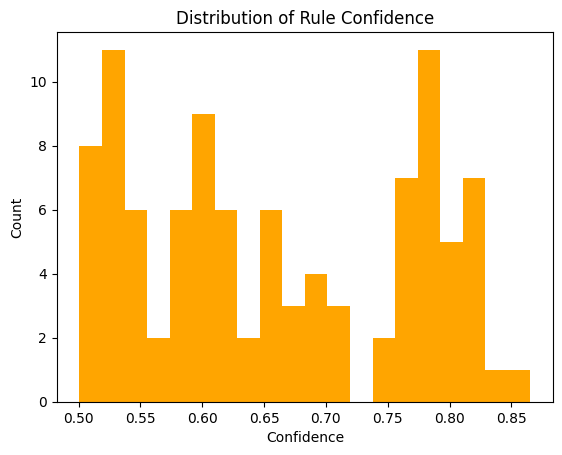

In [26]:
import pyfpgrowth

# Choose support threshold based on percentile (e.g., top 20% most common items)
min_support = 0.01

# Use your data-driven min_support
minsup_count = max(1, int(len(df) * min_support))
freq_items = pyfpgrowth.find_frequent_patterns(df['ingredients'].to_list(), minsup_count)

# Generate rules with a low min_conf to inspect distribution
rules = pyfpgrowth.generate_association_rules(freq_items, 0.5)

# Collect all confidence values
confidences = [conf for (_, (__, conf)) in rules.items()]

# Display stats and histogram
print(pd.Series(confidences).describe())

plt.hist(confidences, bins=20, color='orange')
plt.title("Distribution of Rule Confidence")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()


### Using best parameters

we chose minsupport = 0.01 using elbow method and will use min confidence = 0.79 since it captures the top quartile of high-quality rules for a strong rule zone

In [31]:
import pyfpgrowth
import pandas as pd

# --- Parameters ---
min_support = 0.01
min_confidence = 0.79

# --- Step 1: Compute minsup count ---
num_transactions = len(df['ingredients'])
minsup_count = max(1, int(num_transactions * min_support))

# --- Step 2: Find frequent itemsets ---
freq_itemsets = pyfpgrowth.find_frequent_patterns(df['ingredients'].to_list(), minsup_count)

# --- Step 3: Generate association rules ---
rules = pyfpgrowth.generate_association_rules(freq_itemsets, min_confidence)

# --- Step 4: Add support & lift for each rule ---
def get_support(itemset):
    """Return support of an itemset."""
    return freq_itemsets.get(itemset, 0) / num_transactions

lifted_rules = []
for antecedent, (consequent, confidence) in rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)
    if consequent_support == 0:
        continue
    lift = confidence / consequent_support
    lifted_rules.append((antecedent, consequent, confidence, lift))

# --- Step 5: Sort rules by confidence (and optionally lift) ---
lifted_rules = sorted(lifted_rules, key=lambda x: (x[2], x[3]), reverse=True)

# --- Step 6: Display top 10 rules ---
top10_rules = lifted_rules[:10]
for i, (antecedent, consequent, confidence, lift) in enumerate(top10_rules, start=1):
    print(f"{i}. {set(antecedent)} -> {set(consequent)} "
          f"(confidence = {confidence:.2f}, lift = {lift:.2f})")


1. {'pepper', 'flour'} -> {'salt'} (confidence = 0.87, lift = 2.34)
2. {'butter', 'pepper'} -> {'salt'} (confidence = 0.84, lift = 2.26)
3. {'eggs', 'baking soda', 'baking powder'} -> {'salt'} (confidence = 0.82, lift = 2.20)
4. {'baking soda', 'baking powder', 'sugar'} -> {'salt'} (confidence = 0.81, lift = 2.20)
5. {'all-purpose flour', 'baking powder', 'sugar'} -> {'salt'} (confidence = 0.81, lift = 2.20)
6. {'pepper', 'olive oil'} -> {'salt'} (confidence = 0.81, lift = 2.20)
7. {'eggs', 'baking soda', 'sugar'} -> {'salt'} (confidence = 0.81, lift = 2.20)
8. {'onion', 'pepper'} -> {'salt'} (confidence = 0.81, lift = 2.20)
9. {'eggs', 'all-purpose flour', 'baking powder'} -> {'salt'} (confidence = 0.81, lift = 2.19)
10. {'milk', 'baking powder', 'sugar'} -> {'salt'} (confidence = 0.80, lift = 2.17)


## FIM all ingredients for healthy food filtered by tags


### Get Healthy Recipes

We classified a recipe to be healthy if it has the tags 'healthy' or 'healthy-2'.

In [9]:
# Create a tags presence matrix
mlb = MultiLabelBinarizer()
tags_matrix = mlb.fit_transform(df['tags'])
df_tags_matrix = pd.DataFrame(tags_matrix, columns=mlb.classes_, index=df.index)

# Get the healthy foods based on the tags
is_healthy_tag = df_tags_matrix['healthy'] == 1
is_healthy_2_tag = df_tags_matrix['healthy-2'] == 1
is_health_tag = is_healthy_tag | is_healthy_2_tag
is_healthy_food = df_tags_matrix[is_health_tag].index

df_healthy = df.loc[is_healthy_food]

# Save the csv
pd.Series(is_healthy_food).to_csv('data/is_healthy_food.csv', index=False, header=False)

In [10]:
df_healthy.to_json('data/healthy_foods.json', orient='records')

In [11]:
# filtering for Healthy Foods, we check for the frequent ingredients
num_recipes = len(df_healthy['ingredients'])
min_support_pct = 0.02
minsup_count = max(1, int(num_recipes * min_support_pct))

healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(df_healthy['ingredients'].to_list(), minsup_count)

In [12]:
# Create a dictionary to store counts by itemset length
healthy_freq_counts = defaultdict(int)

for itemset in healthy_freq_ingredients.keys():
    k = len(itemset)  # length of the itemset
    healthy_freq_counts[k] += 1

# Convert to regular dict and optionally sort by k
freq_counts = dict(sorted(healthy_freq_counts.items()))

# Get the healthy itemsets
healthy_three_itemsets = {k: v for k, v in healthy_freq_ingredients.items() if len(k) == 3}


In [13]:
# Sort 3-itemsets by their support count (descending order)
sorted_three_itemsets = sorted(
    healthy_three_itemsets.items(),
    key=lambda x: x[1],  # sort by support count (the value)
    reverse=True         # highest first
)

# Get Top 10 most frequent 3-itemsets
top10_three_itemsets = sorted_three_itemsets[:10]

# Display results neatly
for i, (items, count) in enumerate(top10_three_itemsets, start=1):
    print(f"{i}. {items} -> {count}")


1. ('flour', 'salt', 'sugar') -> 1624
2. ('salt', 'sugar', 'water') -> 1464
3. ('butter', 'salt', 'sugar') -> 1422
4. ('baking powder', 'salt', 'sugar') -> 1351
5. ('milk', 'salt', 'sugar') -> 1167
6. ('eggs', 'salt', 'sugar') -> 1134
7. ('baking powder', 'flour', 'salt') -> 1109
8. ('baking powder', 'baking soda', 'salt') -> 1014
9. ('butter', 'flour', 'salt') -> 987
10. ('garlic cloves', 'olive oil', 'salt') -> 983


### Association Rules

In [14]:
healthy_rules = pyfpgrowth.generate_association_rules(healthy_freq_ingredients, 0.7)

# Total number of transactions (for calculating supports)
num_transactions = len(df_healthy['ingredients'])

# Function to calculate support
def get_support(itemset):
    """Return support of an itemset based on frequency."""
    return healthy_freq_ingredients.get(itemset, 0) / num_transactions

# Recalculate rules with lift
lifted_rules = []

for antecedent, (consequent, confidence) in healthy_rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)

    # Avoid division by zero
    if consequent_support == 0:
        continue

    lift = confidence / consequent_support
    lifted_rules.append((antecedent, consequent, confidence, lift))

# Sort by confidence (and optionally by lift)
lifted_rules = sorted(lifted_rules, key=lambda x: x[2], reverse=True)

# Get Top 10 rules
top10_rules_lift = lifted_rules[:10]

# Display neatly
for i, (antecedent, consequent, confidence, lift) in enumerate(top10_rules_lift, start=1):
    print(f"{i}. {set(antecedent)} -> {set(consequent)} "
          f"(confidence = {confidence:.2f}, lift = {lift:.2f})")


1. {'all-purpose flour', 'sugar'} -> {'salt'} (confidence = 0.82, lift = 2.09)
2. {'all-purpose flour', 'baking powder'} -> {'salt'} (confidence = 0.81, lift = 2.09)
3. {'baking powder', 'sugar'} -> {'salt'} (confidence = 0.79, lift = 2.01)
4. {'baking soda', 'sugar'} -> {'salt'} (confidence = 0.78, lift = 1.99)
5. {'flour', 'baking powder'} -> {'salt'} (confidence = 0.77, lift = 1.98)
6. {'flour', 'sugar'} -> {'salt'} (confidence = 0.76, lift = 1.96)
7. {'baking soda', 'baking powder'} -> {'salt'} (confidence = 0.76, lift = 1.96)
8. {'eggs', 'sugar'} -> {'salt'} (confidence = 0.72, lift = 1.85)
9. {'butter', 'flour'} -> {'salt'} (confidence = 0.71, lift = 1.82)
10. {'butter', 'sugar'} -> {'salt'} (confidence = 0.71, lift = 1.82)


### Hyperparameter tune

count    6176.000000
mean        0.001338
std         0.008797
min         0.000022
25%         0.000044
50%         0.000111
75%         0.000420
max         0.389749
Name: support, dtype: float64


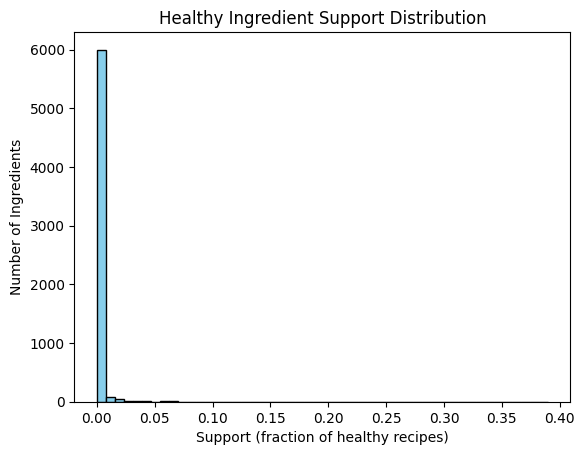

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# --- Count how often each ingredient appears in healthy recipes ---
healthy_ingredient_counts = Counter(
    ing for recipe in df_healthy['ingredients'] for ing in recipe
)

# --- Convert to DataFrame ---
healthy_ingredient_freq = pd.DataFrame.from_dict(
    healthy_ingredient_counts, orient='index', columns=['count']
)

# --- Compute support (fraction of recipes containing the ingredient) ---
healthy_ingredient_freq['support'] = healthy_ingredient_freq['count'] / len(df_healthy)

# --- Sort descending by support ---
healthy_ingredient_freq = healthy_ingredient_freq.sort_values('support', ascending=False)

# --- Display summary statistics for support distribution ---
print(healthy_ingredient_freq['support'].describe())

# --- Plot histogram of supports to visualize potential cutoff points ---
plt.hist(healthy_ingredient_freq['support'], bins=50, color='skyblue', edgecolor='black')
plt.title("Healthy Ingredient Support Distribution")
plt.xlabel("Support (fraction of healthy recipes)")
plt.ylabel("Number of Ingredients")
plt.show()


count    80.000000
mean      0.678648
std       0.121353
min       0.501285
25%       0.561066
50%       0.681223
75%       0.788783
max       0.930748
dtype: float64


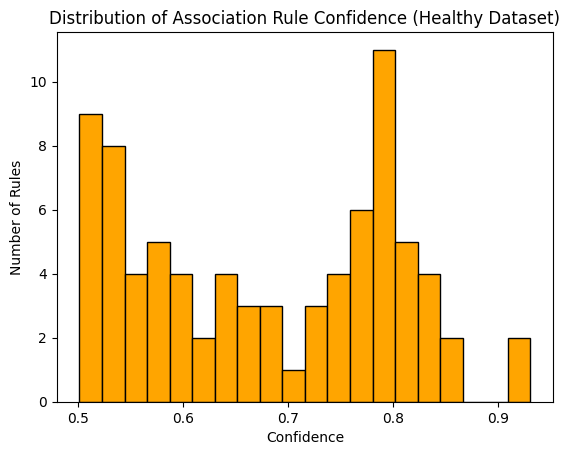

In [30]:
import pyfpgrowth
import pandas as pd
import matplotlib.pyplot as plt

# --- Use the tuned or chosen min_support from Step 1 ---
min_support = 0.01  # example value (you can adjust based on Step 1)

# --- Compute minimum support count ---
minsup_count = max(1, int(len(df_healthy) * min_support))

# --- Mine frequent itemsets for healthy recipes ---
healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(
    df_healthy['ingredients'].to_list(), minsup_count
)

# --- Generate association rules with a LOW confidence threshold ---
# We start low (e.g., 0.5) to capture the full confidence distribution
healthy_rules = pyfpgrowth.generate_association_rules(healthy_freq_ingredients, 0.5)

# --- Extract all confidence values ---
confidences = [conf for (_, (__, conf)) in healthy_rules.items()]

# --- Show descriptive statistics of confidence distribution ---
print(pd.Series(confidences).describe())

# --- Plot histogram of confidence values ---
plt.hist(confidences, bins=20, color='orange', edgecolor='black')
plt.title("Distribution of Association Rule Confidence (Healthy Dataset)")
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.show()


### Using Best Parameters

In [32]:
import pyfpgrowth
import pandas as pd

# --- Set tuned hyperparameters ---
min_support = 0.01
min_confidence = 0.75

# --- Compute minimum support count ---
minsup_count = max(1, int(len(df_healthy) * min_support))

# --- Mine frequent itemsets ---
healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(
    df_healthy['ingredients'].to_list(), minsup_count
)

# --- Generate association rules ---
healthy_rules = pyfpgrowth.generate_association_rules(
    healthy_freq_ingredients, min_confidence
)

# --- Calculate support for each itemset ---
def get_support(itemset):
    """Return support (fraction of transactions)."""
    return healthy_freq_ingredients.get(itemset, 0) / len(df_healthy)

# --- Compute lift for each rule ---
lifted_rules = []
for antecedent, (consequent, confidence) in healthy_rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)

    # Avoid divide-by-zero errors
    if consequent_support == 0:
        continue

    lift = confidence / consequent_support
    lifted_rules.append((antecedent, consequent, confidence, lift))

# --- Sort rules by confidence (and lift) descending ---
lifted_rules = sorted(lifted_rules, key=lambda x: (x[2], x[3]), reverse=True)

# --- Get Top 10 rules ---
top10_rules_lift = lifted_rules[:10]

# --- Display neatly ---
print("Top 10 Association Rules (min_support=0.01, min_confidence=0.75)\n")
for i, (antecedent, consequent, confidence, lift) in enumerate(top10_rules_lift, start=1):
    print(f"{i}. {set(antecedent)} -> {set(consequent)} "
          f"(confidence = {confidence:.2f}, lift = {lift:.2f})")


Top 10 Association Rules (min_support=0.01, min_confidence=0.75)

1. {'bread flour'} -> {'salt'} (confidence = 0.93, lift = 2.39)
2. {'warm water', 'sugar'} -> {'salt'} (confidence = 0.92, lift = 2.35)
3. {'pepper', 'olive oil'} -> {'salt'} (confidence = 0.86, lift = 2.20)
4. {'milk', 'all-purpose flour'} -> {'salt'} (confidence = 0.85, lift = 2.19)
5. {'butter', 'baking powder', 'sugar'} -> {'salt'} (confidence = 0.84, lift = 2.15)
6. {'garlic cloves', 'pepper'} -> {'salt'} (confidence = 0.84, lift = 2.14)
7. {'eggs', 'all-purpose flour'} -> {'salt'} (confidence = 0.83, lift = 2.13)
8. {'onion', 'pepper'} -> {'salt'} (confidence = 0.83, lift = 2.12)
9. {'milk', 'flour', 'sugar'} -> {'salt'} (confidence = 0.82, lift = 2.10)
10. {'water', 'pepper'} -> {'salt'} (confidence = 0.82, lift = 2.10)


### Compare if the frequent ingredients in all and healthy-only recipes are similar

We use the Jaccard index as a way to measure similarity. Since the similarity is 0.52 between the frequent ingredient itemsets of all recipes and healthy-only recipes, this indicates that there is only a moderate overlap between the two groups. In other words, nearly half of the commonly used ingredients in healthy recipes are not the same as those in the general recipe population. This suggests that healthy recipes rely on a distinct set of ingredients, reflecting meaningful differences in ingredient composition and dietary choices.

In [16]:
def jaccard_index(list1, list2):
    set1 = set(list1)
    set2 = set(list2)

    if not set1 and not set2:
        return 0  # avoid division by zero when both lists are empty

    intersection = len(set1 & set2)  # common elements
    union = len(set1 | set2)         # total unique elements
    return intersection / union

jaccard_index(list(all_freq_ingredients.keys()), list(healthy_freq_ingredients.keys()))

0.5284974093264249

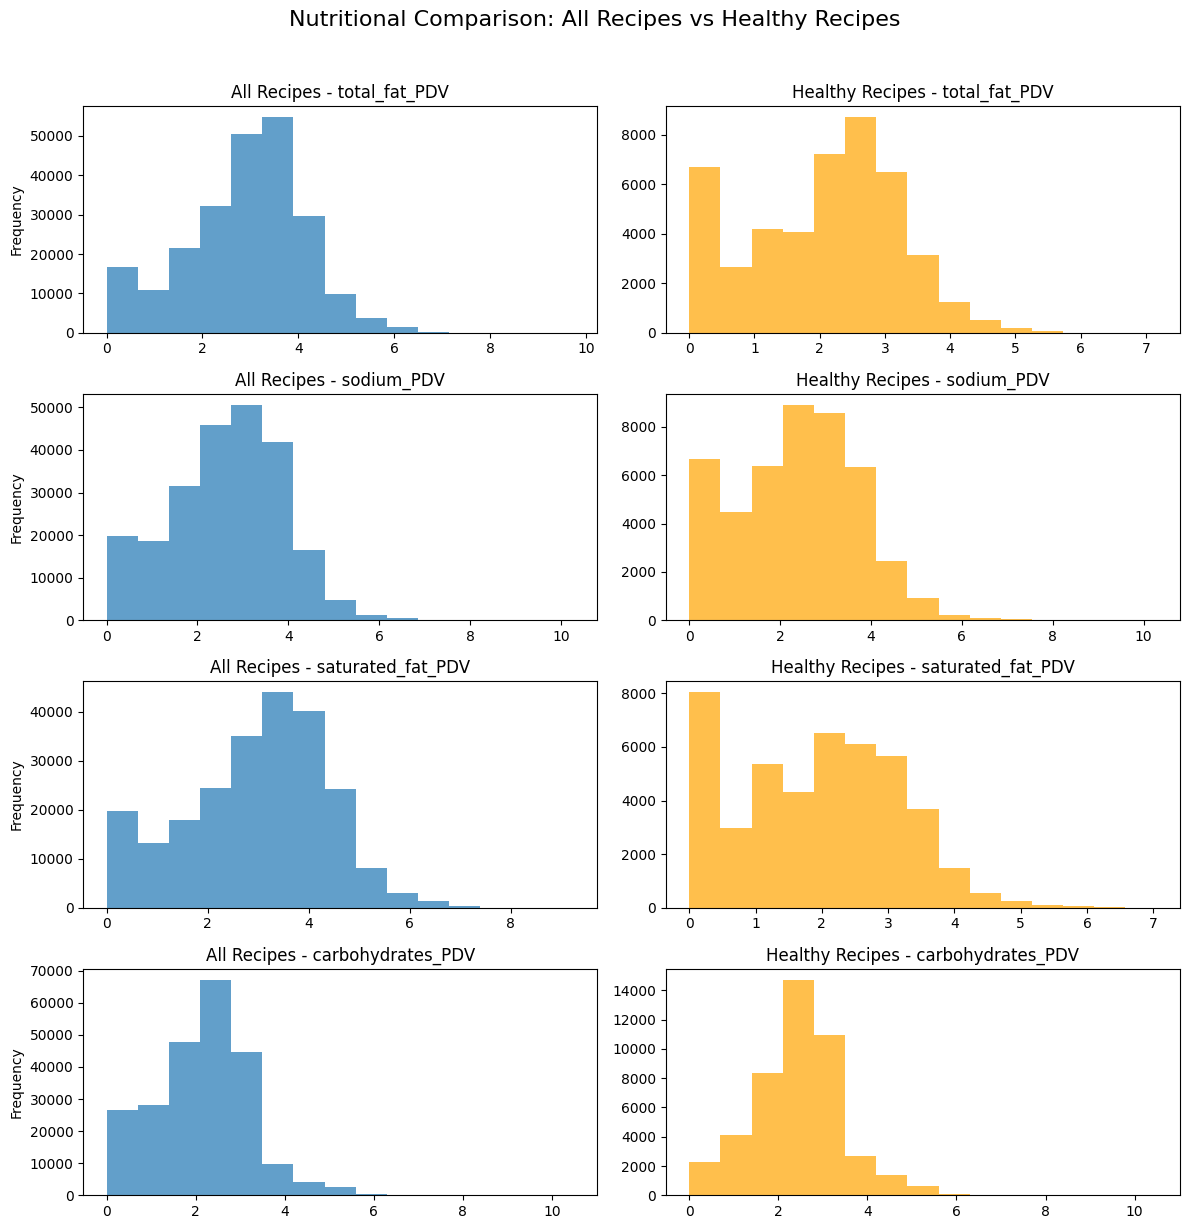

In [17]:
nutrition_cols = [
    "calories",
    "total_fat_PDV",
    "sugar_PDV",
    "sodium_PDV",
    "protein_PDV",
    "saturated_fat_PDV",
    "carbohydrates_PDV",
]

df_all_nutritions = df["nutrition"].apply(pd.Series)
df_all_nutritions.columns = nutrition_cols

df_healthy_nutritions = df_healthy["nutrition"].apply(pd.Series)
df_healthy_nutritions.columns = nutrition_cols

# Now select only the 4 you want to visualize
selected_cols = ["total_fat_PDV", "sodium_PDV", "saturated_fat_PDV", "carbohydrates_PDV"]

fig, axes = plt.subplots(nrows=len(selected_cols), ncols=2, figsize=(12, 12))
fig.suptitle("Nutritional Comparison: All Recipes vs Healthy Recipes", fontsize=16, y=1.02)

for i, col in enumerate(selected_cols):
    axes[i, 0].hist(np.log1p(df_all_nutritions[col].dropna()), bins=15, alpha=0.7)
    axes[i, 0].set_title(f"All Recipes - {col}")
    axes[i, 0].set_ylabel("Frequency")

    axes[i, 1].hist(np.log1p(df_healthy_nutritions[col].dropna()), bins=15, alpha=0.7, color="orange")
    axes[i, 1].set_title(f"Healthy Recipes - {col}")

plt.tight_layout()
plt.show()


We also check the differences in the distribution of the nutritional values between all the recipes and just the healthy recipes. We see that most of them are similar, except for total_fat_PDV and saturated_fat_PDV. THis makes sense because like...yeahh....

## FIM both ingredients for healthy food and tags


We do FIM on both ingredients for healthy food with tags to uncover links between ingredients and recipe tags, showing which ingredients characterize certain recipe types.


In [35]:
from collections import defaultdict
import pyfpgrowth

# --- Combine tags and ingredients ---
df_healthy['tags_ingredients'] = df_healthy.apply(
    lambda row: row['tags'] + row['ingredients'], axis=1
)

# --- Set minimum support threshold ---
num_recipes = len(df['ingredients'])
min_support_pct = 0.02
minsup_count = max(1, int(num_recipes * min_support_pct))

# --- Find frequent patterns using FP-Growth ---
healthy_freq_tags_ingredient = pyfpgrowth.find_frequent_patterns(
    df_healthy['tags_ingredients'].to_list(),
    minsup_count
)

# --- Count itemsets by their length ---
tags_ingr_counts = defaultdict(int)
for itemset in healthy_freq_tags_ingredient.keys():
    k = len(itemset)
    tags_ingr_counts[k] += 1

# --- Convert to dict for reference ---
tags_ingr_counts = dict(sorted(tags_ingr_counts.items()))
print("Itemset counts by length:", tags_ingr_counts)
print()

# --- Filter only 3-itemsets ---
three_itemsets_tags_ingr = {
    k: v for k, v in healthy_freq_tags_ingredient.items() if len(k) == 3
}

# --- Sort 3-itemsets by support count (descending order) ---
sorted_three_itemsets_tags_ingr = sorted(
    three_itemsets_tags_ingr.items(),
    key=lambda x: x[1],
    reverse=True
)

# --- Get top 10 3-itemsets ---
top10_three_itemsets_tags_ingr = sorted_three_itemsets_tags_ingr[:10]

# --- Display neatly ---
print("Top 10 Frequent 3-Itemsets (Tags + Ingredients):\n")
for i, (items, count) in enumerate(top10_three_itemsets_tags_ingr, start=1):
    print(f"{i}. {set(items)} -> {count}")


Itemset counts by length: {1: 5, 2: 258, 3: 2155, 4: 7797, 5: 16372, 6: 23050, 7: 23047, 8: 16788, 9: 8958, 10: 3456, 11: 926, 12: 152, 13: 10}

Top 10 Frequent 3-Itemsets (Tags + Ingredients):

1. {'preparation', 'dietary', 'time-to-make'} -> 44097
2. {'preparation', 'dietary', 'course'} -> 42420
3. {'preparation', 'time-to-make', 'course'} -> 41507
4. {'dietary', 'time-to-make', 'course'} -> 41507
5. {'preparation', 'dietary', 'low-in-something'} -> 40631
6. {'healthy', 'preparation', 'dietary'} -> 40236
7. {'preparation', 'time-to-make', 'low-in-something'} -> 39718
8. {'dietary', 'time-to-make', 'low-in-something'} -> 39718
9. {'healthy', 'preparation', 'time-to-make'} -> 39345
10. {'healthy', 'dietary', 'time-to-make'} -> 39345


### Association Rules

In [36]:
import pandas as pd
import pyfpgrowth

# --- Generate association rules from tag+ingredient itemsets ---
min_confidence = 0.7
healthy_tag_rules = pyfpgrowth.generate_association_rules(healthy_freq_tags_ingredient, min_confidence)

# --- Compute total transactions ---
num_transactions = len(df_healthy['tags_ingredients'])

# --- Helper function: get support of an itemset ---
def get_support(itemset):
    return healthy_freq_tags_ingredient.get(itemset, 0) / num_transactions

# --- Compute lift for each rule ---
lifted_tag_rules = []
for antecedent, (consequent, confidence) in healthy_tag_rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)

    # avoid divide-by-zero
    if consequent_support == 0:
        continue

    lift = confidence / consequent_support
    lifted_tag_rules.append((antecedent, consequent, confidence, lift))

# --- Sort rules by confidence (and lift) descending ---
lifted_tag_rules = sorted(lifted_tag_rules, key=lambda x: (x[2], x[3]), reverse=True)

# --- Get Top 10 rules ---
top10_tag_rules = lifted_tag_rules[:10]

# --- Display neatly ---
print("Top 10 Association Rules (Tags + Ingredients, min_conf=0.7):\n")
for i, (antecedent, consequent, confidence, lift) in enumerate(top10_tag_rules, start=1):
    print(f"{i}. {set(antecedent)} -> {set(consequent)} "
          f"(confidence = {confidence:.2f}, lift = {lift:.2f})")


Top 10 Association Rules (Tags + Ingredients, min_conf=0.7):

1. {'american', 'time-to-make', 'course'} -> {'preparation', 'dietary', 'north-american', 'cuisine'} (confidence = 1.00, lift = 4.86)
2. {'main-ingredient', 'american', 'time-to-make', 'course'} -> {'preparation', 'dietary', 'north-american', 'cuisine'} (confidence = 1.00, lift = 4.86)
3. {'cuisine', 'american', 'time-to-make', 'course'} -> {'preparation', 'dietary', 'north-american'} (confidence = 1.00, lift = 4.86)
4. {'dietary', 'american', 'time-to-make', 'course'} -> {'preparation', 'north-american', 'cuisine'} (confidence = 1.00, lift = 4.86)
5. {'main-ingredient', 'cuisine', 'course', 'american', 'time-to-make'} -> {'preparation', 'dietary', 'north-american'} (confidence = 1.00, lift = 4.86)
6. {'main-ingredient', 'course', 'dietary', 'time-to-make', 'american'} -> {'preparation', 'north-american', 'cuisine'} (confidence = 1.00, lift = 4.86)
7. {'cuisine', 'course', 'dietary', 'time-to-make', 'american'} -> {'preparat

### Hyperparameter tune

Support Summary for Tags + Ingredients:

count    6571.000000
mean        0.004704
std         0.040505
min         0.000022
25%         0.000044
50%         0.000111
75%         0.000553
max         1.000000
Name: support, dtype: float64


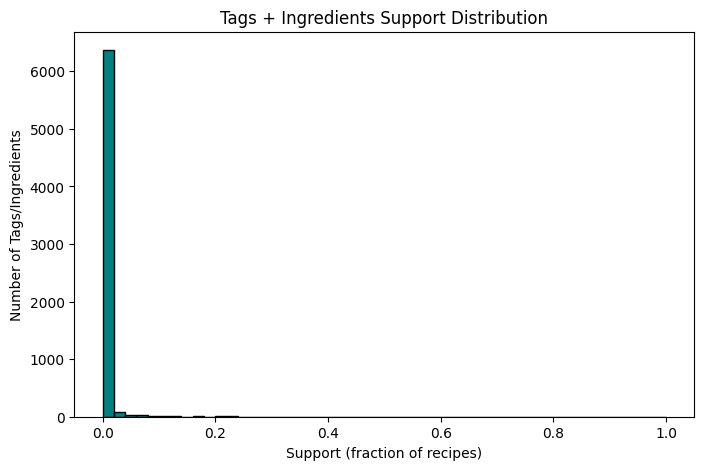

In [37]:
# --- Step 1: Count how often each tag/ingredient appears ---
tag_ingr_counts = Counter(
    item for recipe in df_healthy['tags_ingredients'] for item in recipe
)

# --- Step 2: Convert to DataFrame ---
tag_ingr_freq = pd.DataFrame.from_dict(tag_ingr_counts, orient='index', columns=['count'])
tag_ingr_freq['support'] = tag_ingr_freq['count'] / len(df_healthy)

# --- Step 3: Sort descending by support ---
tag_ingr_freq = tag_ingr_freq.sort_values('support', ascending=False)

# --- Step 4: Show summary statistics ---
print("Support Summary for Tags + Ingredients:\n")
print(tag_ingr_freq['support'].describe())

# --- Step 5: Plot support distribution ---
plt.figure(figsize=(8,5))
plt.hist(tag_ingr_freq['support'], bins=50, color='teal', edgecolor='black')
plt.title("Tags + Ingredients Support Distribution")
plt.xlabel("Support (fraction of recipes)")
plt.ylabel("Number of Tags/Ingredients")
plt.show()

Found 1335332 frequent itemsets (min_support=0.04)

Confidence Summary for Tags + Ingredients:
count    1.328789e+06
mean     9.944352e-01
std      1.546389e-02
min      5.535996e-01
25%      9.983356e-01
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


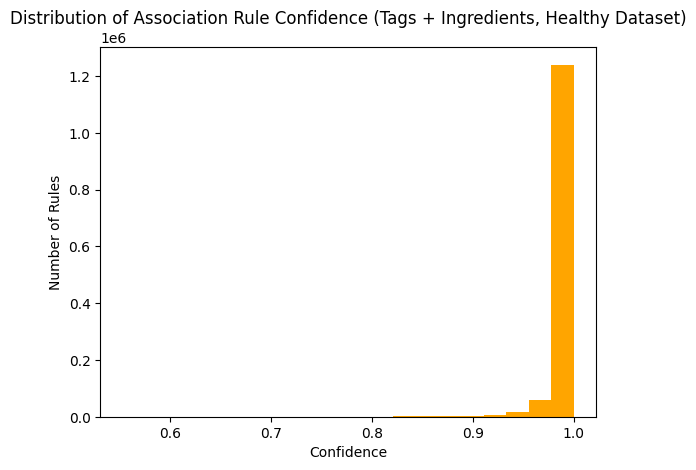

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import pyfpgrowth

# --- Step 1: Set minimum support ---
min_support = 0.04  # based on elbow analysis
minsup_count = max(1, int(len(df_healthy) * min_support))

# --- Step 2: Find frequent patterns (tags + ingredients) ---
freq_tags_ingr = pyfpgrowth.find_frequent_patterns(
    df_healthy['tags_ingredients'].to_list(),
    minsup_count
)

print(f"Found {len(freq_tags_ingr)} frequent itemsets (min_support={min_support})")

# --- Step 3: Generate association rules with a low confidence to inspect distribution ---
rules_tags_ingr = pyfpgrowth.generate_association_rules(freq_tags_ingr, 0.5)

# --- Step 4: Collect confidence values ---
confidences = [conf for (_, (__, conf)) in rules_tags_ingr.items()]

# --- Step 5: Display confidence stats ---
print("\nConfidence Summary for Tags + Ingredients:")
print(pd.Series(confidences).describe())

# --- Step 6: Plot histogram of confidence values ---
plt.hist(confidences, bins=20, color='orange')
plt.title("Distribution of Association Rule Confidence (Tags + Ingredients, Healthy Dataset)")
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.show()


### Using best parameters




In [41]:
import pandas as pd
import pyfpgrowth

# Generate association rules (min_conf = 0.95)
healthy_tag_rules_95 = pyfpgrowth.generate_association_rules(freq_tags_ingr, 0.95)

# Convert to readable list
rules_list = []
for antecedent, (consequent, metrics) in healthy_tag_rules_95.items():
    # Handle both possible return formats
    if isinstance(metrics, tuple):
        support, confidence = metrics
    else:
        support, confidence = None, metrics

    rules_list.append((set(antecedent), set(consequent), confidence))

# Sort by confidence descending
rules_list = sorted(rules_list, key=lambda x: x[2], reverse=True)

# Print top 10 rules
print("Top 10 Association Rules (Tags + Ingredients, min_conf = 0.95):\n")
for i, (antecedent, consequent, confidence) in enumerate(rules_list[:10], start=1):
    print(f"{i}. {antecedent} -> {consequent} (confidence = {confidence:.2f})")


Top 10 Association Rules (Tags + Ingredients, min_conf = 0.95):

1. {'vanilla', 'dietary'} -> {'preparation'} (confidence = 1.00)
2. {'healthy', 'vanilla'} -> {'preparation', 'dietary'} (confidence = 1.00)
3. {'preparation', 'vanilla'} -> {'dietary'} (confidence = 1.00)
4. {'healthy', 'vanilla', 'dietary'} -> {'preparation'} (confidence = 1.00)
5. {'healthy', 'preparation', 'vanilla'} -> {'dietary'} (confidence = 1.00)
6. {'vanilla', 'time-to-make'} -> {'preparation', 'dietary'} (confidence = 1.00)
7. {'vanilla', 'time-to-make', 'course'} -> {'preparation', 'dietary'} (confidence = 1.00)
8. {'vanilla', 'dietary', 'time-to-make'} -> {'preparation'} (confidence = 1.00)
9. {'preparation', 'vanilla', 'time-to-make'} -> {'dietary'} (confidence = 1.00)
10. {'vanilla', 'dietary', 'time-to-make', 'course'} -> {'preparation'} (confidence = 1.00)
